# **Pembangunan Model Deep Learning**

# 1. Pembangunan Model Multi-Layer Perceptron dengan Representasi Fitur TF-IDF

Loaded shapes: (6226, 2000) (1352, 2000) (6226,) (1352,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,024,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,188,865 (4.54 MB)

 Trainable params: 1,188,865 (4.54 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


195/195 - 360s - 2s/step - accuracy: 0.9863 - loss: 0.0673 - val_accuracy: 0.9993 - val_loss: 9.6790e-04
Epoch 2/50
195/195 - 172s - 882ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.9993 - val_loss: 0.0011
Epoch 3/50
195/195 - 144s - 736ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9993 - val_loss: 0.0014
Epoch 4/50
195/195 - 90s - 461ms/step - accuracy: 0.9998 - loss: 8.7064e-04 - val_accuracy: 0.9993 - val_loss: 0.0017
Epoch 5/50
195/195 - 78s - 400ms/step - accuracy: 0.9998 - loss: 7.9654e-04 - val_accuracy: 0.9985 - val_loss: 0.0023
Epoch 6/50
195/195 - 53s - 271ms/step - accuracy: 0.9998 - loss: 5.2418e-04 - val_accuracy: 0.9985 - val_loss: 0.0076
MLP (TF-IDF) Test Accuracy: 0.9993
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 174ms/step


              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[777   1]
 [  0 574]]


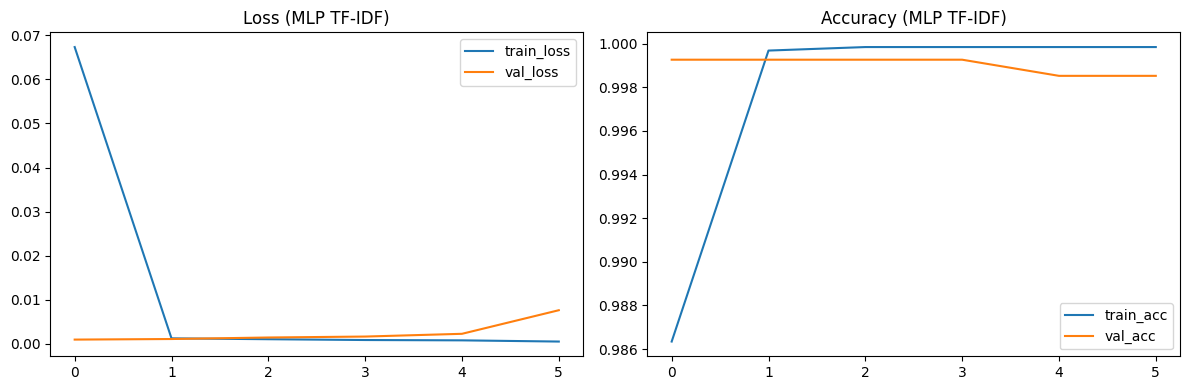

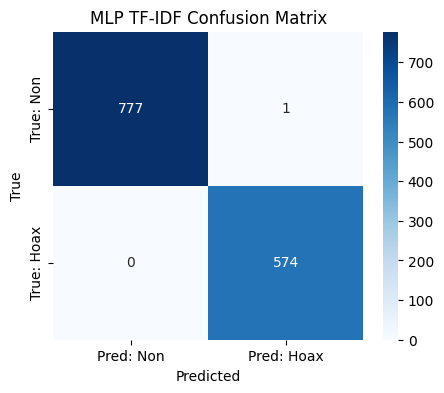

In [ ]:
# ===== MLP (TF-IDF, fitur hasil SelectKBest chi2) =====
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Load selected features (Chi2) ----------
X_train, X_test, y_train, y_test = joblib.load("selected_features_chi2.joblib")
print("Loaded shapes:", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Ensure numpy arrays
if not isinstance(X_train, (np.ndarray,)):
    X_train = X_train.astype(np.float32)
if not isinstance(X_test, (np.ndarray,)):
    X_test = X_test.astype(np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_test = np.array(y_test, dtype=np.int32)

# ---------- 2. Build MLP ----------
input_dim = X_train.shape[1]
model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------- 3. Callbacks ----------
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
mc = ModelCheckpoint("mlp_tfidf_best.h5", monitor='val_loss', save_best_only=True)

# ---------- 4. Train ----------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[es, mc],
    verbose=2
)

# ---------- 5. Evaluate ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"MLP (TF-IDF) Test Accuracy: {acc:.4f}")

y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Non-Hoax", "Hoax"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ---------- 6. Save model + history ----------
model.save("mlp_tfidf_final.h5")
joblib.dump(history.history, "mlp_tfidf_history.joblib")

# ---------- 7. Plot training curves ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss (MLP TF-IDF)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy (MLP TF-IDF)')
plt.legend()
plt.tight_layout()
plt.savefig("mlp_tfidf_training_curves.png", dpi=150)
plt.show()

# ---------- 8. Confusion matrix heatmap (save) ----------
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred: Non","Pred: Hoax"], yticklabels=["True: Non","True: Hoax"])
plt.title("MLP TF-IDF Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.savefig("mlp_tfidf_confusion.png", dpi=150)
plt.show()


# 2. Pembangunan Model BiLSTM dengan Representasi Word2Vec

Vocab size (used): 30001
Word2Vec dim: 100
Embedding matrix shape: (30001, 100)
Train/test shapes: (5408, 120) (1352, 120)
Class weights: {0: np.float64(0.8686154834564729), 1: np.float64(1.1782135076252724)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     3,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,100 (11.44 MB)

 Trainable params: 0 (0.00 B)

...

85/85 - 16s - 190ms/step - accuracy: 0.9861 - loss: 0.0634 - val_accuracy: 0.9970 - val_loss: 0.0108
Epoch 2/15


85/85 - 3s - 35ms/step - accuracy: 0.9976 - loss: 0.0104 - val_accuracy: 0.9993 - val_loss: 0.0047
Epoch 3/15


85/85 - 4s - 46ms/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.9993 - val_loss: 0.0044
Epoch 4/15


85/85 - 3s - 31ms/step - accuracy: 0.9996 - loss: 0.0015 - val_accuracy: 0.9993 - val_loss: 0.0026
Epoch 5/15
85/85 - 3s - 34ms/step - accuracy: 0.9919 - loss: 0.0306 - val_accuracy: 0.9719 - val_loss: 0.1168
Epoch 6/15
85/85 - 2s - 25ms/step - accuracy: 0.9871 - loss: 0.0412 - val_accuracy: 0.9948 - val_loss: 0.0163
Epoch 7/15
85/85 - 4s - 45ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9948 - val_loss: 0.0149
Epoch 8/15
85/85 - 4s - 45ms/step - accuracy: 0.9982 - loss: 0.0049 - val_accuracy: 0.9956 - val_loss: 0.0107
BiLSTM Test Accuracy: 0.9992603659629822
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step


              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[777   1]
 [  0 574]]


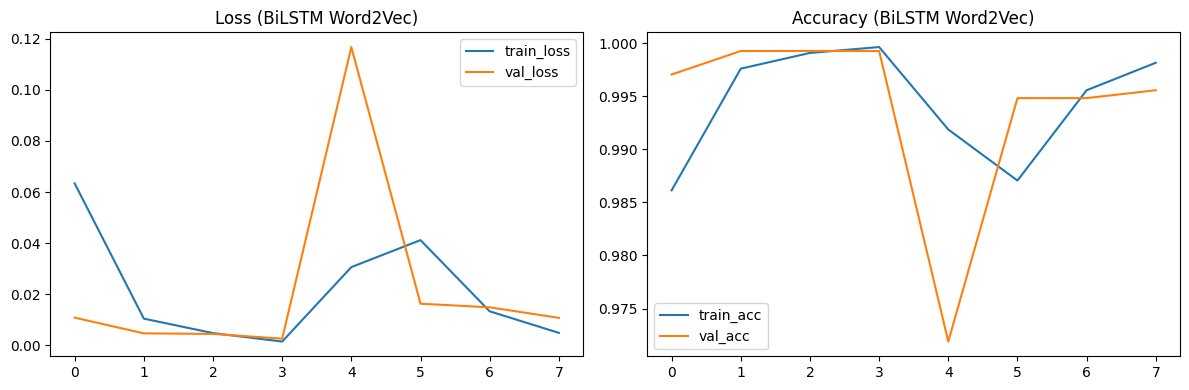

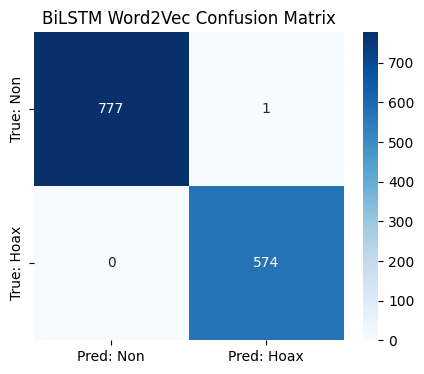

In [ ]:
# ===== LSTM (Word2Vec) using embedding matrix from gensim model =====
import numpy as np
import pandas as pd
from gensim.models import Word2Vec, KeyedVectors
import joblib
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- 1. Load data & gensim model ----------
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")  # <-- path from your upload
texts = df["teks_final"].astype(str).tolist()
labels = df["label_num"].values

# ---------- 2. Tokenizer ----------
MAX_VOCAB = 30000   # or None to use entire
tok = Tokenizer(oov_token="<OOV>", num_words=MAX_VOCAB)
tok.fit_on_texts(texts)
word_index = tok.word_index
vocab_size = min(MAX_VOCAB, len(word_index)) + 1
print("Vocab size (used):", vocab_size)

# ---------- 3. Load Word2Vec (gensim) ----------
w2v_model = Word2Vec.load("word2vec_model.model")  # ensure this file exists
embed_dim = w2v_model.vector_size
print("Word2Vec dim:", embed_dim)

# ---------- 4. Build embedding matrix ----------
embedding_matrix = np.zeros((vocab_size, embed_dim), dtype=np.float32)
for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
# save embedding for re-use
np.save("embedding_matrix_w2v.npy", embedding_matrix)
print("Embedding matrix shape:", embedding_matrix.shape)

# ---------- 5. Convert texts -> sequences ----------
sequences = tok.texts_to_sequences(texts)
MAXLEN = 120  # choose based on distribution of doc lengths
X = pad_sequences(sequences, maxlen=MAXLEN, padding='post', truncating='post')
y = labels

# ---------- 6. Train-test split (stratify) ----------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# ---------- 7. Compute class weights to handle imbalance ----------
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i : class_weights[i] for i in range(len(class_weights))}
print("Class weights:", class_weight_dict)

# ---------- 8. Build BiLSTM model ----------
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embed_dim, weights=[embedding_matrix], input_length=MAXLEN, trainable=False),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# ---------- 9. Callbacks ----------
es = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
mc = ModelCheckpoint("bilstm_w2v_best.h5", monitor='val_loss', save_best_only=True)

# ---------- 10. Train ----------
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[es, mc],
    verbose=2
)

# ---------- 11. Evaluate ----------
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print("BiLSTM Test Accuracy:", acc)

y_proba = model.predict(X_test).ravel()
y_pred = (y_proba >= 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=["Non-Hoax", "Hoax"]))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ---------- 12. Save artifacts ----------
model.save("bilstm_w2v_final.h5")
joblib.dump(tok, "tokenizer_w2v.joblib")
np.save("embedding_matrix_w2v.npy", embedding_matrix)
joblib.dump(history.history, "bilstm_w2v_history.joblib")

# ---------- 13. Plot training curves & confusion ----------
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss (BiLSTM Word2Vec)')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy (BiLSTM Word2Vec)')
plt.legend()
plt.tight_layout()
plt.savefig("bilstm_w2v_training_curves.png", dpi=150)
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Pred: Non","Pred: Hoax"], yticklabels=["True: Non","True: Hoax"])
plt.title("BiLSTM Word2Vec Confusion Matrix")
plt.savefig("bilstm_w2v_confusion.png", dpi=150)
plt.show()


# Pembangunan Model Transfer Learning Menggunakan IndoBERT (Fine-Tuned)

In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q transformers datasets tokenizers accelerate scikit-learn seqeval


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ================================================================
# 0) INSTALL PACKAGE (WAJIB JALANKAN SEKALI)
# ================================================================
!pip install -q transformers==4.30.0 datasets==2.12.0 accelerate
import os
os.environ["WANDB_DISABLED"] = "true"   # matikan wandb


# ================================================================
# 1) IMPORT LIBRARY
# ================================================================
import random, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset


# ================================================================
# 2) KONFIGURASI
# ================================================================
MODEL_NAME = "indobenchmark/indobert-base-p2"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 3
SEED = 42
OUTPUT_DIR = "./indobert_hoax"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ================================================================
# 3) LOAD DATASET
# Pastikan file memiliki kolom: teks_final, label_num
# ================================================================
df = pd.read_csv("dataset_ready_for_feature_extraction.csv")

print("Total data:", df.shape)
print(df.head())

df["label_num"] = df["label_num"].astype(int)


# ================================================================
# 4) TRAIN / TEST SPLIT
# ================================================================
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_num"],
    random_state=SEED
)

print("Train:", train_df.shape, "Test:", test_df.shape)


# ================================================================
# 5) CONVERT KE DATASET HUGGINGFACE
# ================================================================
train_ds = Dataset.from_pandas(
    train_df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
)

test_ds = Dataset.from_pandas(
    test_df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
)


# ================================================================
# 6) LOAD TOKENIZER & MODEL INDO-BERT
# ================================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)


# ================================================================
# 7) TOKENISASI
# ================================================================
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

train_ds = train_ds.remove_columns(["text"])
test_ds  = test_ds.remove_columns(["text"])

train_ds.set_format("torch")
test_ds.set_format("torch")


# ================================================================
# 8) TRAINING ARGUMENTS (VERSI KOMPATIBEL)
# Tanpa evaluation_strategy karena versi Transformers Anda tidak mendukung
# ================================================================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=EPOCHS,
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
)


# ================================================================
# 9) DEFINE TRAINER
# ================================================================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer
)


# ================================================================
# 10) TRAIN MODEL
# ================================================================
trainer.train()


# ================================================================
# 11) MANUAL EVALUATION (KARENA TRAINING ARGUMENT MINIMAL)
# ================================================================
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = pred.label_ids

print("\n====================")
print("EVALUATION RESULT")
print("====================")
print("Accuracy :", accuracy_score(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Hoax","Hoax"]))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


# ================================================================
# 12) SAVE MODEL
# ================================================================
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("\nModel saved to:", OUTPUT_DIR)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.9/314.9 kB 10.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.6/474.6 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 10.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projec

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Map:   0%|          | 0/5408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1352 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-314268730.py:125: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
100,0.051100
200,0.006200
300,0.009800
400,0.000100
500,0.000100
600,0.009800
700,0.000100
800,0.000000
900,0.000000
1000,0.000000



EVALUATION RESULT
Accuracy : 1.0

Classification Report:
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352


Confusion Matrix:
[[778   0]
 [  0 574]]

Model saved to: ./indobert_hoax


# Transfer Learning pada IndoBERT dengan Optimisasi LoRA

In [ ]:
# ============================
# IndoBERT + LoRA (PEFT) — Full script
# Run this in Google Colab (GPU runtime)
# ============================

# 0) (Optional) Jika tokenizers sering gagal di-build, jalankan dulu:
# !pip install tokenizers==0.13.3 --prefer-binary

# 1) Install required packages (run once)
!pip install -q transformers==4.30.0 datasets==2.12.0 accelerate peft==0.5.1

import os
os.environ["WANDB_DISABLED"] = "true"   # matikan wandb (opsional)

# 2) Imports
import random
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from peft import LoraConfig, get_peft_model, TaskType

# 3) Config — sesuaikan sesuai kebutuhan / VRAM
MODEL_NAME = "indobenchmark/indobert-base-p2"
DATA_PATH = "dataset_ready_for_feature_extraction.csv"  # pastikan file ada
OUTPUT_DIR = "./indobert_lora"
SEED = 42

MAX_LEN = 128            # kurangi ke 96/64 bila ingin lebih cepat
EPOCHS = 3
BATCH_SIZE = 16          # ubah sesuai VRAM; bila OOM turunkan ke 8/4
LR = 2e-4                # LoRA sering pakai LR sedikit lebih tinggi (1e-4..3e-4)
LORA_R = 8               # rank (8 umum dipakai)
LORA_ALPHA = 32
LORA_DROPOUT = 0.1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4) Load dataset (harus memiliki kolom: teks_final, label_num)
df = pd.read_csv(DATA_PATH)
assert "teks_final" in df.columns and "label_num" in df.columns, "File harus mengandung 'teks_final' dan 'label_num'."

# keep only needed columns and ensure int labels
df = df[["teks_final", "label_num"]].rename(columns={"teks_final":"text", "label_num":"label"})
df["label"] = df["label"].astype(int)

# 5) Train/test split (stratified)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print("Train distribution:\n", train_df["label"].value_counts())
print("Test distribution:\n", test_df["label"].value_counts())

# 6) Convert to HF Dataset
train_ds = Dataset.from_pandas(train_df)
test_ds  = Dataset.from_pandas(test_df)

# 7) Tokenizer + model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

# Load base model (classification head will be randomly initialized)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# 8) LoRA (PEFT) config and wrap
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,   # classification task
    inference_mode=False,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",                  # keep bias handling simple
    target_modules=["query", "key", "value"]  # for BERT-like models
)

model = get_peft_model(model, lora_config)
print("LoRA adapters added. Trainable params (approx):")
for n, p in model.named_parameters():
    if p.requires_grad:
        print(n, p.shape)

# 9) Tokenization (use dynamic padding later via DataCollator)
def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_ds = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_ds  = test_ds.map(tokenize_fn, batched=True, remove_columns=["text"])

# set formats
train_ds.set_format(type="torch")
test_ds.set_format(type="torch")

# 10) Data collator (dynamic padding)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 11) Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="binary", zero_division=0)
    return {"accuracy": acc, "precision": p, "recall": r, "f1": f1}

# 12) TrainingArguments — keep minimal / compatible
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LR,
    logging_steps=50,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),   # use mixed precision if GPU available
    remove_unused_columns=False,
)

# 13) Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# 14) Train (only LoRA params will be updated)
trainer.train()

# 15) Evaluate
pred = trainer.predict(test_ds)
logits = pred.predictions
y_pred = np.argmax(logits, axis=1)
y_true = pred.label_ids

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["Non-Hoax","Hoax"]))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# 16) Save LoRA adapters + tokenizer (small)
model.save_pretrained(OUTPUT_DIR)             # saves base_model + adapters in peft format
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved LoRA model + tokenizer to", OUTPUT_DIR)

# Optional: To load later:
# from peft import PeftModel
# base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# lora_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
# lora_model.eval()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 3.7 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement peft==0.5.1 (from versions: 0.0.1, 0.0.2, 0.1.0, 0.2.0, 0.3.0, 0.4.0, 0.5.0, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.8.0, 0.8.1, 0.8.2, 0.9.0, 0.10.0, 0.11.0, 0.11.1, 0.12.0, 0.13.0, 0.13.1, 0.13.2, 0.14.0, 0.15.0, 0.15.1, 0.15.2, 0.16.0, 0.17.0, 0.17.1, 0.18.0rc0, 0.18.0)
ERROR: No matching distribution found for peft==0.5.1
Train distribution:
 label
0    3113
1    2295
Name: count, dtype: int64
Test distribution:
 label
0    778
1    574
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Map:   0%|          | 0/5408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1352 [00:00<?, ? examples/s]

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-2711861362.py:134: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
50,0.364700
100,0.007000
150,0.002300
200,0.007800
250,0.008500
300,0.001100
350,0.002100
400,0.000300
450,0.000200
500,0.000200


Accuracy: 1.0
              precision    recall  f1-score   support

    Non-Hoax       1.00      1.00      1.00       778
        Hoax       1.00      1.00      1.00       574

    accuracy                           1.00      1352
   macro avg       1.00      1.00      1.00      1352
weighted avg       1.00      1.00      1.00      1352

Confusion Matrix:
 [[778   0]
 [  0 574]]
Saved LoRA model + tokenizer to ./indobert_lora


**Visualisasi Kurva Training Loss pada Model IndoBERT dengan LoRA**

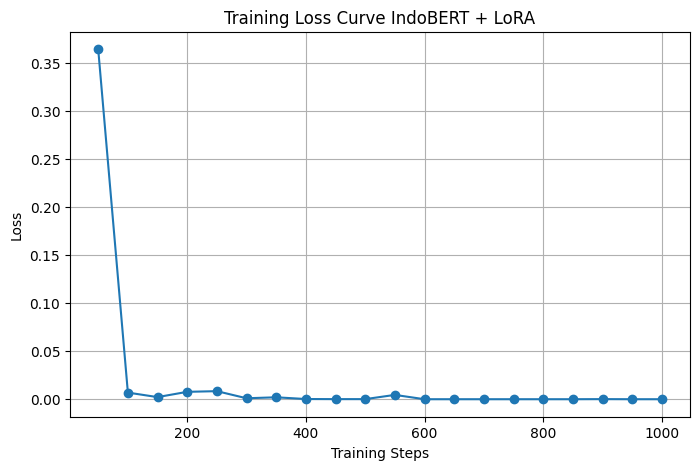

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def plot_training_loss(trainer):
    logs = trainer.state.log_history
    steps = []
    losses = []

    for log in logs:
        if "loss" in log:
            steps.append(log["step"])
            losses.append(log["loss"])

    plt.figure(figsize=(8, 5))
    plt.plot(steps, losses, marker='o')
    plt.title("Training Loss Curve IndoBERT + LoRA")
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

plot_training_loss(trainer)


**Visualisasi Confusion Matrix untuk Model IndoBERT dengan LoRA**

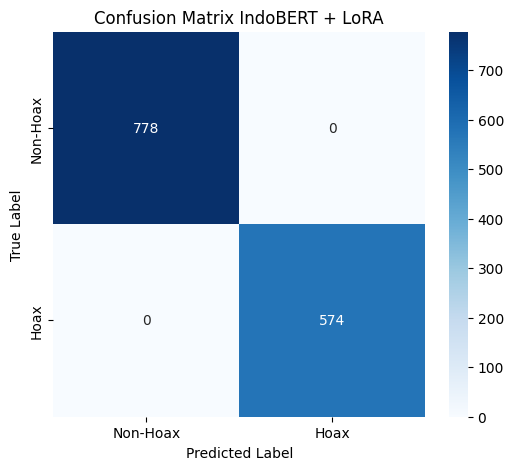

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Hoax", "Hoax"],
            yticklabels=["Non-Hoax", "Hoax"])
plt.title("Confusion Matrix IndoBERT + LoRA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred)

metrics_df = pd.DataFrame({
    "Class": ["Non-Hoax", "Hoax"],
    "Precision": prec,
    "Recall": rec,
    "F1-score": f1,
    "Support": sup
})

metrics_df


,Class,Precision,Recall,F1-score,Support
0,Non-Hoax,1.0,1.0,1.0,778
1,Hoax,1.0,1.0,1.0,574
